## 回归分析基本概念


以一元线性方程为例

**假设函数**:
$h_\theta(x)=\theta_0+\theta_1x$

**参数**:
$\theta_0,\theta_1$

**代价函数**:
$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}{(h_\theta(x^i) - y^i)^2}$

**目标**:
$\underset{\theta_0, \theta_1}{minimize}J(\theta_0, \theta_1)$

## 线性回归的SKlearn实现

### 导入相关包

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_boston
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

plt.rcParams['font.sans-serif'] = ['simhei'] #显示中文
plt.rcParams['font.sans-serif'] = 'Hiragino Sans GB'   # mac
plt.rcParams['axes.unicode_minus'] = False   #用来正常显示负号
%matplotlib inline

### 查看波士顿地区房价数据描述

CRIM：城镇人均犯罪率。

ZN：住宅用地超过 25000 sq.ft. 的比例。

INDUS：城镇非零售商用土地的比例。

CHAS：查理斯河空变量（如果边界是河流，则为1；否则为0）。

NOX：一氧化氮浓度。

RM：住宅平均房间数。

AGE：1940 年之前建成的自用房屋比例。

DIS：到波士顿五个中心区域的加权距离。

RAD：辐射性公路的接近指数。

TAX：每 10000 美元的全值财产税率。

PTRATIO：城镇师生比例。

B：1000（Bk-0.63）^ 2，其中 Bk 指代城镇中黑人的比例。

LSTAT：人口中地位低下者的比例。

MEDV：自住房的平均房价，以千美元计。

In [2]:
housePrice = load_boston()
 
print(housePrice.DESCR)

.. _boston_dataset:

Boston house prices dataset
---------------------------

**Data Set Characteristics:**  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per $10,000
        - PTRATIO  pu

### 数据分割

In [3]:
X = housePrice.data
y = housePrice.target.reshape(-1, 1)
 
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123)

### 训练与测试数据标准化处理

In [4]:
scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train)
 
X_train = scaler_X.transform(X_train)
X_test = scaler_X.transform(X_test)
y_train = scaler_y.transform(y_train)
y_test = scaler_y.transform(y_test)

### 线性模型

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_lr_predict = lr.predict(X_test)
y_lr_predict = scaler_y.inverse_transform(y_lr_predict)

# 常数项
print(lr.intercept_)
# 变量系数
print(lr.coef_)

[2.54604869e-15]
[[-0.09486201  0.10311529  0.04373625  0.03166336 -0.19272026  0.33406022
  -0.00142284 -0.31207492  0.26088133 -0.22606321 -0.21635916  0.06520126
  -0.42370605]]


In [6]:
print("lr的均方误差为:{}".format(mean_squared_error(scaler_y.inverse_transform(y_test), y_lr_predict)))

lr的均方误差为:24.768530968608626


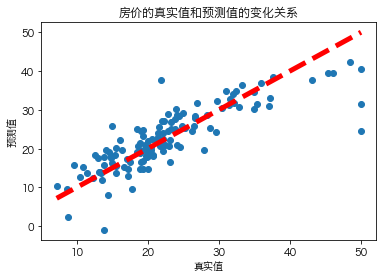

In [7]:
mormal_y = scaler_y.inverse_transform(y_test)
fig, ax = plt.subplots()
ax.scatter(mormal_y, y_lr_predict)
ax.plot([mormal_y.min(), mormal_y.max()], [mormal_y.min(), mormal_y.max()], 'r--', lw=5)
ax.set_xlabel('真实值')
ax.set_ylabel('预测值')
plt.title('房价的真实值和预测值的变化关系')
plt.show()